In [1]:
import os
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


# 1. Импорты и фиксация seed

# 2. Данные и первичный анализ

In [2]:
dataset = load_dataset("dair-ai/emotion", trust_remote_code=True)

print("Размеры сплитов:")
for split in dataset.keys():
    print(f"{split}: {len(dataset[split])}")

class_names = dataset["train"].features["label"].names
print("\nКлассы:", class_names)

print("\nПримеры:")
for i in range(5):
    item = dataset["train"][i]
    print(f"Текст: {item['text']} | Метка: {class_names[item['label']]} ({item['label']})")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'dair-ai/emotion' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Размеры сплитов:
train: 16000
validation: 2000
test: 2000

Классы: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

Примеры:
Текст: i didnt feel humiliated | Метка: sadness (0)
Текст: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake | Метка: sadness (0)
Текст: im grabbing a minute to post i feel greedy wrong | Метка: anger (3)
Текст: i am ever feeling nostalgic about the fireplace i will know that it is still on the property | Метка: love (2)
Текст: i am feeling grouchy | Метка: anger (3)


# 3. Токенизация

In [3]:

from transformers import BertTokenizer

model_name = "google/bert_uncased_L-2_H-128_A-2" 
tokenizer = BertTokenizer.from_pretrained(model_name)

texts_to_tokenize = [dataset["train"][i]["text"] for i in range(3)]
tok_out = tokenizer(texts_to_tokenize, padding=True, truncation=True, max_length=128, return_tensors="pt")

print("Пример токенизации:\n")
for i, text in enumerate(texts_to_tokenize):
    print(f"Оригинал: {text}")
    print(f"Токены: {tokenizer.convert_ids_to_tokens(tok_out['input_ids'][i])}")
    print(f"Input IDs: {tok_out['input_ids'][i]}")
    print(f"Attention mask: {tok_out['attention_mask'][i]}\n")

Пример токенизации:

Оригинал: i didnt feel humiliated
Токены: ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
Input IDs: tensor([  101,  1045,  2134,  2102,  2514, 26608,   102,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0])
Attention mask: tensor([1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

Оригинал: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Токены: ['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake', '[SEP]']
Input IDs: tensor([  101,  1045,  2064,  2175,  2013,  3110,  2061, 20625,  2000,  2061,
         9636, 17772,  2074,  201

# 4. Инференс готовой модели

In [4]:
sentiment_pipeline = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english", device=0 if device=="cuda" else -1)

print("Инференс готовой модели (distilbert SST-2):")
for text in texts_to_tokenize:
    res = sentiment_pipeline(text)[0]
    print(f"Текст: '{text}' -> {res['label']} ({res['score']:.3f})")

print("\nГотовая модель distilbert-sst2 обучена на позитив/негатив, а наша задача - 6 эмоций, поэтому ее напрямую не применить. Нужен fine-tuning.")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Инференс готовой модели (distilbert SST-2):
Текст: 'i didnt feel humiliated' -> POSITIVE (0.891)
Текст: 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake' -> POSITIVE (0.967)
Текст: 'im grabbing a minute to post i feel greedy wrong' -> NEGATIVE (0.999)

Готовая модель distilbert-sst2 обучена на позитив/негатив, а наша задача - 6 эмоций, поэтому ее напрямую не применить. Нужен fine-tuning.


# 5. Fine-tuning для классификации текста

In [5]:
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=64)

tokenized_datasets = dataset.map(tokenize_function, batched=True)

# Для ускорения обрежем train
small_train_dataset = tokenized_datasets["train"].shuffle(seed=42).select(range(4000))
small_eval_dataset = tokenized_datasets["validation"].shuffle(seed=42).select(range(1000))
small_test_dataset = tokenized_datasets["test"].shuffle(seed=42).select(range(1000))

In [6]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=6)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='macro')
    return {"accuracy": acc, "f1_macro": f1}

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=5e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=50,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train_dataset,
    eval_dataset=small_eval_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()

Loading weights:   0%|          | 0/39 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google/bert_uncased_L-2_H-128_A-2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
c:\Users\fahitalis\Co

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.589635,1.582618,0.369000,0.096983
2,1.567940,1.573566,0.399000,0.139124


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\fahitalis\Courses\mirea-aie\mirea-aie-student\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.beta', 'bert.embeddings.LayerNorm.gamma', 'bert.encoder.layer.0.attention.output.LayerNorm.beta', 'bert.encoder.layer.0.attention.output.LayerNorm.gamma', 'bert.encoder.layer.0.output.LayerNorm.beta', 'bert.encoder.layer.0.output.LayerNorm.gamma', 'bert.encoder.layer.1.attention.output.LayerNorm.beta', 'bert.encoder.layer.1.attention.output.LayerNorm.gamma', 'bert.en

TrainOutput(global_step=250, training_loss=1.5928490600585938, metrics={'train_runtime': 25.6095, 'train_samples_per_second': 312.384, 'train_steps_per_second': 9.762, 'total_flos': 1272072192000.0, 'train_loss': 1.5928490600585938, 'epoch': 2.0})

# 6. Оценка качества и краткий анализ ошибок

c:\Users\fahitalis\Courses\mirea-aie\mirea-aie-student\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Результаты на тесте: {'test_loss': 1.5365588665008545, 'test_accuracy': 0.388, 'test_f1_macro': 0.12782543916564534, 'test_runtime': 0.65, 'test_samples_per_second': 1538.55, 'test_steps_per_second': 49.234}


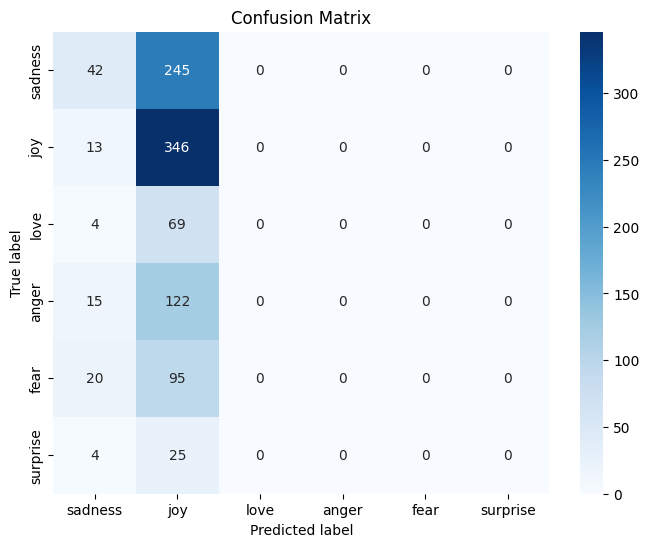

,text,true_label,pred_label,confidence
0,i was feeling really troubled and down over wh...,sadness,sadness,0.303262
1,i feel so thrilled to have three such distingu...,joy,joy,0.359611
2,i feel is that the most likeable characters ar...,joy,joy,0.346655
3,i tune out the rest of the world and focus on ...,joy,joy,0.344912
4,i sit here writing this i feel unhappy inside,sadness,joy,0.315261
5,im feeling and if ive liked being pregnant,love,joy,0.318865
6,im very hurt and i feel unimportant,sadness,joy,0.305928
7,i used to be able to hang around talk with the...,anger,joy,0.338450
8,i don t have the feeling of divine vibrations,joy,joy,0.304420
9,i vented my feelings towards the pathetic excu...,sadness,joy,0.324759


In [7]:
# Оценка на тесте
results = trainer.predict(small_test_dataset)
print("Результаты на тесте:", results.metrics)

predictions = np.argmax(results.predictions, axis=-1)
true_labels = results.label_ids

os.makedirs("artifacts", exist_ok=True)

# Сохранение матрицы ошибок
cm = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix')
plt.savefig("artifacts/confusion_matrix.png")
plt.show()

# Сохранение sample predictions
sample_df = pd.DataFrame({
    'text': [small_test_dataset[i]['text'] for i in range(len(small_test_dataset))],
    'true_label': [class_names[l] for l in true_labels],
    'pred_label': [class_names[p] for p in predictions],
    'confidence': np.max(torch.nn.functional.softmax(torch.tensor(results.predictions), dim=-1).numpy(), axis=-1)
})

sample_df.head(10).to_csv("artifacts/sample_predictions.csv", index=False)
sample_df.head(10)

In [8]:
# Краткий анализ ошибок
errors = sample_df[sample_df['true_label'] != sample_df['pred_label']]
print("Анализ ошибок: примеры где модель ошиблась\n")
for idx, row in errors.head(5).iterrows():
    print(f"Текст: {row['text']}")
    print(f"Истинная: {row['true_label']} | Предсказанная: {row['pred_label']} ({row['confidence']:.2f})\n")

print("Модель `bert-tiny` с малым количеством эпох путается в семантически похожих эмоциях (например, sadness и anger, или joy и surprise), так как ей не хватает емкости для глубокого понимания контекста.")

Анализ ошибок: примеры где модель ошиблась

Текст: i sit here writing this i feel unhappy inside
Истинная: sadness | Предсказанная: joy (0.32)

Текст: im feeling and if ive liked being pregnant
Истинная: love | Предсказанная: joy (0.32)

Текст: im very hurt and i feel unimportant
Истинная: sadness | Предсказанная: joy (0.31)

Текст: i used to be able to hang around talk with the cashier when i was putting away my money now i feel rushed and stressed if i take a second to fumble with the coins and put them in my purse
Истинная: anger | Предсказанная: joy (0.34)

Текст: i vented my feelings towards the pathetic excuse of a communicat
Истинная: sadness | Предсказанная: joy (0.32)

Модель `bert-tiny` с малым количеством эпох путается в семантически похожих эмоциях (например, sadness и anger, или joy и surprise), так как ей не хватает емкости для глубокого понимания контекста.
